In [41]:
pop_file = "GHS_POP_E2025_GLOBE_R2023A_4326_30ss_V1_0.tif"
import rioxarray as rxr

pop = rxr.open_rasterio(pop_file)

print(pop)

<xarray.DataArray (band: 1, y: 21384, x: 43202)> Size: 7GB
[923831568 values with dtype=float64]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 346kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
  * y            (y) float64 171kB 89.1 89.09 89.08 ... -89.08 -89.09 -89.1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_MAXIMUM:        286330.44519772
    STATISTICS_MEAN:           8.8674048604304
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         249.62729204313
    STATISTICS_VALID_PERCENT:  100
    scale_factor:              1.0
    add_offset:                0.0


In [42]:
import rioxarray as rxr
import xarray as xr

pop_file = "GHS_POP_E2025_GLOBE_R2023A_4326_30ss_V1_0.tif"

# =========================================================
# 1. lazy load + chunk
# =========================================================
pop = rxr.open_rasterio(
    pop_file,
    chunks={"x": 2048, "y": 2048}   # ⭐关键
)

pop = pop.squeeze()
pop = pop.rename({"x": "lon", "y": "lat"})
pop = pop.sortby("lat")
pop.name = "population"

if "spatial_ref" in pop.coords:
    pop = pop.drop_vars("spatial_ref")

# =========================================================
# 2. coarsen (lazy execution)
# =========================================================
pop_1deg = pop.coarsen(
    lat=120,
    lon=120,
    boundary="trim"
).sum()

# =========================================================
# 3. trigger compute ONLY at end
# =========================================================
pop_1deg = pop_1deg.compute()

print(pop_1deg)

# =========================================================
# 4. save to NetCDF
# =========================================================
output_nc = "population_1deg_2025.nc"

pop_1deg.to_netcdf(
    output_nc,
    format="NETCDF4",
    engine="netcdf4"
)

print(f"Saved to: {output_nc}")

<xarray.DataArray 'population' (lat: 178, lon: 360)> Size: 513kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(178, 360))
Coordinates:
    band     int64 8B 1
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 1kB -88.6 -87.6 -86.6 -85.6 ... 85.4 86.4 87.4 88.4
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_MAXIMUM:        286330.44519772
    STATISTICS_MEAN:           8.8674048604304
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         249.62729204313
    STATISTICS_VALID_PERCENT:  100
    scale_factor:              1.0
    add_offset:                0.0
Saved to: population_1deg_2025.nc


In [44]:
print(pop_1deg.max().values)
print(pop_1deg.sum().values)

40608432.262861855
8191987080.671857


In [43]:
import xarray as xr

ds = xr.open_dataset("population_1deg_2025.nc")

print(ds)

<xarray.Dataset> Size: 517kB
Dimensions:     (lon: 360, lat: 178)
Coordinates:
    band        int64 8B ...
  * lon         (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * lat         (lat) float64 1kB -88.6 -87.6 -86.6 -85.6 ... 86.4 87.4 88.4
Data variables:
    population  (lat, lon) float64 513kB ...


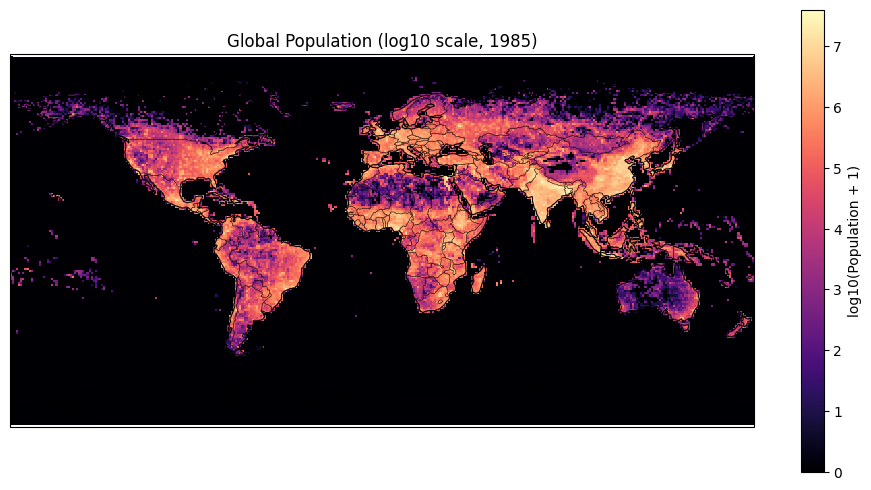

In [45]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# =========================================================
# 1. 读取数据
# =========================================================
ds = xr.open_dataset("population_1deg_2025.nc")
pop = ds["population"]

# =========================================================
# 2. log10 变换（避免 log(0)）
# =========================================================
pop_log = np.log10(pop + 1)

# =========================================================
# 3. 绘图
# =========================================================
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# =========================================================
# 4. plot log10 population
# =========================================================
im = pop_log.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="magma",
    cbar_kwargs={"label": "log10(Population + 1)"}
)

# =========================================================
# 5. map features
# =========================================================
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.set_global()

ax.set_title("Global Population (log10 scale, 1985)")

plt.show()